# Lezione 4 — Probabilità, variabili casuali e valori attesi condizionati in Python

**Versione docente completa**

Caso applicativo: **rendimenti e perdite di un portafoglio finanziario a un periodo con stati informativi di mercato**.

La lezione usa una simulazione Monte Carlo per tradurre in procedure computabili alcuni oggetti introdotti nei Capitoli 1--3:

- variabile casuale discreta di stato $Z$;
- rendimento aleatorio $R$;
- perdita $L=-V_0R$;
- eventi di superamento soglia;
- probabilità empiriche;
- valori attesi non condizionati;
- valori attesi condizionati rispetto a eventi e partizioni informative;
- costruzione computazionale della variabile $\mathbb{E}[L\mid\mathcal{G}]$.

Il notebook è organizzato per **domande probabilistiche**, non per librerie Python.

Le formule nelle celle di testo usano sintassi Markdown/Jupyter: `$...$` per formule inline e `$$...$$` per formule display.

## Struttura operativa

Il notebook è pensato per essere eseguito in VS Code/Jupyter.

Destinazioni previste:

```text
04_Codice/
`-- Lez04_probabilita_condizionamento_docente.ipynb

graphics/
|-- Cap04_istogramma_perdita.png
|-- Cap04_ecdf_perdita.png
|-- Cap04_quantili_perdita.png
|-- Cap04_medie_condizionate_stati.png
|-- Cap04_prob_superamento_soglie.png
|-- Cap04_distribuzioni_condizionate.png
|-- Cap04_sensibilita_M.png
`-- Cap04_partizioni_informative.png
```

Le tabelle CSV prodotte dal notebook sono salvate in una sottocartella locale di lavoro:

```text
04_Codice/output_Lez04/
```

Questa scelta mantiene il codice in `04_Codice/`, le figure in `graphics/`, e i file intermedi in una cartella separata.

## Tappa 0 — Intestazione, librerie e riproducibilità

**Obiettivo.** Fissare le impostazioni generali del modello computazionale.

**Controllo.** Verificare che $M>0$, $V_0>0$ e $\ell>0$.

**Interpretazione.** Il seed rende l'esperimento Monte Carlo riproducibile. Il parametro $M$ può essere ridotto a $50$ per una preview didattica, ma la versione docente usa un valore più alto per ottenere stime più stabili.

In [3]:
# ============================================================
# Blocco 0.1 - Librerie di lavoro
# ============================================================
# Path serve per costruire percorsi di file e cartelle in modo robusto.
# E' preferibile a scrivere percorsi come semplici stringhe, perche' rende
# piu' chiaro dove vengono salvati grafici e tabelle.
from pathlib import Path

# NumPy e' la libreria di base per vettori, numeri casuali e calcoli numerici.
import numpy as np

# pandas permette di organizzare i dati in tabelle, chiamate DataFrame.
# Nel notebook useremo DataFrame per scenari simulati, frequenze e statistiche.
import pandas as pd

# matplotlib.pyplot e' la libreria usata per costruire i grafici.
import matplotlib.pyplot as plt

# ============================================================
# Blocco 0.2 - Impostazioni di visualizzazione
# ============================================================
# Queste opzioni non modificano i dati: regolano solo come pandas mostra
# le tabelle dentro Jupyter.
pd.set_option("display.precision", 6)
pd.set_option("display.max_columns", 20)

# ============================================================
# Blocco 0.3 - Cartelle di output
# ============================================================
# Path.cwd() restituisce la cartella da cui il notebook viene eseguito.
# In questo progetto il notebook si trova in 04_Codice/.
NOTEBOOK_DIR = Path.cwd()

# I grafici del progetto devono essere salvati nella cartella comune graphics/.
GRAPHICS_DIR = NOTEBOOK_DIR.parent / "graphics"

# Le tabelle numeriche della Lezione 4 vengono salvate in una sottocartella
# dedicata, cosi' restano separate dagli altri materiali del corso.
OUTPUT_DIR = NOTEBOOK_DIR / "output_Lez04"

# mkdir(..., exist_ok=True) crea le cartelle se non esistono gia'.
# Se esistono, non genera errore.
GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Blocco 0.4 - Parametri generali della simulazione
# ============================================================
# Il seed rende riproducibili i numeri casuali: rieseguendo il notebook
# si ottengono gli stessi scenari simulati.
seed = 202604
rng = np.random.default_rng(seed)

# M e' il numero di repliche Monte Carlo, cioe' il numero di scenari simulati.
# Versione docente: usare M elevato.
# Per una preview d'aula si puo' impostare M = 50.
M = 50_000

# V0 e' il valore iniziale del portafoglio. La perdita sara' definita come
# L = -V0 * R, dove R e' il rendimento simulato.
V0 = 100.0

# ell_base e soglie_base sono soglie di perdita usate per stimare probabilita'
# del tipo Prob(L > ell).
ell_base = 5.0
soglie_base = np.array([2.0, 5.0, 8.0, 10.0])

# ============================================================
# Blocco 0.5 - Controlli minimi sui parametri
# ============================================================
# assert verifica che una condizione sia vera. Se non lo e', Python interrompe
# l'esecuzione e mostra il messaggio indicato. Qui serve a intercettare subito
# parametri incoerenti.
assert M > 0, "Il numero di simulazioni deve essere positivo."
assert V0 > 0, "Il valore iniziale del portafoglio deve essere positivo."
assert ell_base > 0, "La soglia di perdita deve essere positiva."

# ============================================================
# Blocco 0.6 - Tabella riassuntiva dei parametri
# ============================================================
# Un DataFrame e' una tabella con righe e colonne. Qui raccogliamo i parametri
# principali in modo che il notebook documenti esplicitamente l'esperimento.
tabella_generale = pd.DataFrame({
    "parametro": ["seed", "M", "V0", "soglia_base"],
    "valore": [seed, M, V0, ell_base]
})

# In Jupyter, lasciare il nome di un oggetto nell'ultima riga della cella
# mostra automaticamente il suo contenuto.
tabella_generale

,parametro,valore
0,seed,202604.0
1,M,50000.0
2,V0,100.0
3,soglia_base,5.0


## Tappa 1 — Definizione degli stati informativi di mercato

Si introduce una variabile discreta di stato

$$ Z\in\{N,V,S\},$$
dove $N$ indica un mercato normale, $V$ una fase di volatilità elevata e $S$ uno stato di stress.

Condizionatamente allo stato $Z=g$, il rendimento del portafoglio è simulato come$$R\mid Z=g \sim \mathcal{N}(\mu_g,\sigma_g^2).$$

**Controllo.** Le probabilità degli stati devono sommare a $1$, essere strettamente positive e le volatilità devono essere positive.

**Interpretazione.** Gli stati generano la partizione informativa rispetto alla quale saranno calcolate le previsioni condizionate.

In [31]:
# ============================================================
# Blocco 1.1 - Stati informativi del mercato
# ============================================================
# Gli stati rappresentano l'informazione disponibile prima di simulare
# il rendimento. Sono le classi della partizione informativa.
stati = np.array(["N", "V", "S"])

# Dizionario per tradurre le sigle in etichette leggibili nei grafici
# e nelle tabelle.
etichette = {
    "N": "mercato normale",
    "V": "volatilità elevata",
    "S": "stress"
}

# ============================================================
# Blocco 1.2 - Probabilita' e parametri condizionati
# ============================================================
# p contiene le probabilita' teoriche degli stati N, V e S.
p = np.array([0.70, 0.20, 0.10])

# mu e sigma descrivono la distribuzione del rendimento R condizionata
# allo stato informativo: R | stato ~ Normale(mu, sigma).
mu = np.array([0.004, -0.006, -0.030])
sigma = np.array([0.020, 0.045, 0.080])

# ============================================================
# Blocco 1.3 - Controlli di coerenza
# ============================================================
# Le probabilita' devono sommare a 1 e devono essere positive.
# Le volatilita' devono essere positive per poter simulare una normale.
assert np.isclose(p.sum(), 1.0), "Le probabilità degli stati non sommano a 1."
assert np.all(p > 0), "Ogni stato deve avere probabilità positiva."
assert np.all(sigma > 0), "Ogni volatilità condizionata deve essere positiva."

# ============================================================
# Blocco 1.4 - Tabella dei parametri del modello
# ============================================================
# La tabella collega a ogni stato la sua probabilita' e i parametri della
# distribuzione condizionata dei rendimenti.
df_parametri = pd.DataFrame({
    "stato": stati,
    "descrizione": [etichette[s] for s in stati],
    "probabilita_teorica": p,
    "mu_rendimento": mu,
    "sigma_rendimento": sigma
})

# set_index("stato") permette poi di recuperare velocemente mu e sigma
# partendo dalla sigla dello stato, ad esempio "N" oppure "S".
param_map = df_parametri.set_index("stato")

df_parametri

,stato,descrizione,probabilita_teorica,mu_rendimento,sigma_rendimento
0,N,mercato normale,0.7,0.004,0.020
1,V,volatilità elevata,0.2,-0.006,0.045
2,S,stress,0.1,-0.030,0.080


## Tappa 2 — Simulazione degli stati informativi

Si simulano $M$ realizzazioni della variabile discreta $Z$.

La frequenza empirica dello stato $g$ è

$$\widehat{p}_g
=
\frac{1}{M}\sum_{k=1}^{M}\mathbf{1}_{\{Z^{(k)}=g\}}.$$

**Controllo.** Le frequenze empiriche devono sommare a $M$; con $M$ elevato devono essere vicine alle probabilità teoriche.

**Interpretazione.** La simulazione traduce la distribuzione teorica degli stati in scenari osservabili.

In [32]:
# ============================================================
# Blocco 2.1 - Simulazione degli stati informativi
# ============================================================
# rng.choice estrae M stati dall'insieme stati, usando le probabilita' p.
# Il risultato Z e' un vettore lungo M: ogni elemento e' lo stato dello scenario k.
Z = rng.choice(stati, size=M, p=p)

# Costruiamo la tabella principale degli scenari simulati.
# scenario va da 1 a M; stato contiene N, V oppure S.
df = pd.DataFrame({
    "scenario": np.arange(1, M + 1),
    "stato": Z
})

# ============================================================
# Blocco 2.2 - Frequenze empiriche degli stati
# ============================================================
# value_counts conta quante volte compare ciascuno stato.
# reindex(stati) impone l'ordine N, V, S anche se pandas userebbe un altro ordine.
freq_emp = (
    df["stato"]
    .value_counts(normalize=False)
    .reindex(stati, fill_value=0)
    .rename("frequenza")
    .reset_index()
    .rename(columns={"index": "stato"})
)

# Uniamo frequenze simulate e probabilita' teoriche per confrontarle.
df_frequenze = (
    df_parametri[["stato", "descrizione", "probabilita_teorica"]]
    .merge(freq_emp, on="stato")
)

# La frequenza relativa e' la stima Monte Carlo della probabilita' dello stato.
df_frequenze["frequenza_relativa"] = df_frequenze["frequenza"] / M

# Lo scarto misura l'errore campionario rispetto alla probabilita' teorica.
df_frequenze["scarto_freq_prob"] = (
    df_frequenze["frequenza_relativa"] 
    - df_frequenze["probabilita_teorica"]
)

# ============================================================
# Blocco 2.3 - Controlli sulla simulazione degli stati
# ============================================================
# Le frequenze devono sommare al numero totale di scenari.
assert df_frequenze["frequenza"].sum() == M, "Le frequenze non sommano a M."

# Con M elevato ci aspettiamo che ogni stato compaia almeno una volta.
assert (df_frequenze["frequenza"] > 0).all(), "Almeno uno stato non è rappresentato."

df_frequenze

,stato,descrizione,probabilita_teorica,frequenza,frequenza_relativa,scarto_freq_prob
0,N,mercato normale,0.7,35071,0.70142,0.00142
1,V,volatilità elevata,0.2,9920,0.19840,-0.00160
2,S,stress,0.1,5009,0.10018,0.00018


## Tappa 3 — Simulazione dei rendimenti condizionati agli stati

Per ogni scenario $k$, si assegna la coppia $(\mu_{Z^{(k)}},\sigma_{Z^{(k)}})$ e si simula

$$R^{(k)} \sim \mathcal{N}(\mu_{Z^{(k)}},\sigma_{Z^{(k)}}^2).$$

**Controllo.** Non devono esserci valori mancanti; le statistiche empiriche per stato devono essere ragionevolmente coerenti con i parametri teorici.

**Interpretazione.** La distribuzione non condizionata di $R$ è una miscela di distribuzioni condizionate agli stati.

In [6]:
# ============================================================
# Blocco 3.1 - Associazione dei parametri allo scenario
# ============================================================
# map usa lo stato simulato di ogni riga per recuperare il valore corretto
# di mu e sigma dalla tabella param_map.
df["mu"] = df["stato"].map(param_map["mu_rendimento"])
df["sigma"] = df["stato"].map(param_map["sigma_rendimento"])

# ============================================================
# Blocco 3.2 - Simulazione del rendimento condizionato
# ============================================================
# rng.normal accetta vettori per loc e scale: in questo modo ogni scenario
# viene simulato dalla normale corrispondente al suo stato informativo.
df["R"] = rng.normal(
    loc=df["mu"].to_numpy(),
    scale=df["sigma"].to_numpy()
)

# ============================================================
# Blocco 3.3 - Controlli sui rendimenti simulati
# ============================================================
# Verifichiamo che il numero di scenari sia rimasto M e che non siano comparsi
# valori mancanti nei parametri o nei rendimenti.
assert len(df) == M, "Il numero di scenari non coincide con M."
assert df[["mu", "sigma", "R"]].notna().all().all(), "Sono presenti valori mancanti."

# ============================================================
# Blocco 3.4 - Confronto tra parametri teorici e statistiche empiriche
# ============================================================
# groupby("stato") raggruppa gli scenari per classe informativa.
# agg calcola, per ogni gruppo, numerosita', media e deviazione standard.
df_stat_R_stato = (
    df.groupby("stato")
    .agg(
        M_g=("R", "size"),
        media_R_empirica=("R", "mean"),
        mu_teorico=("mu", "first"),
        sd_R_empirica=("R", "std"),
        sigma_teorico=("sigma", "first")
    )
    .reindex(stati)
    .reset_index()
)

# Aggiungiamo etichette leggibili e riordiniamo le colonne per la lettura.
df_stat_R_stato["descrizione"] = df_stat_R_stato["stato"].map(etichette)
df_stat_R_stato = df_stat_R_stato[
    ["stato", "descrizione", "M_g", "media_R_empirica", "mu_teorico", "sd_R_empirica", "sigma_teorico"]
]

df_stat_R_stato

,stato,descrizione,M_g,media_R_empirica,mu_teorico,sd_R_empirica,sigma_teorico
0,N,mercato normale,34935,0.004030,0.004,0.019970,0.020
1,V,volatilità elevata,9995,-0.005548,-0.006,0.044905,0.045
2,S,stress,5070,-0.029729,-0.030,0.079179,0.080


## Tappa 4 — Trasformazione dei rendimenti in perdite

La perdita monetaria del portafoglio è definita da

$$L=-V_0R.$$

**Controllo.** Se $R^{(k)}<0$, allora $L^{(k)}>0$; se $R^{(k)}>0$, allora $L^{(k)}<0$.

**Interpretazione.** La coda destra di $L$ rappresenta gli scenari sfavorevoli.

In [7]:
# ============================================================
# Blocco 4.1 - Dal rendimento alla perdita
# ============================================================
# Definiamo la perdita come L = -V0 * R.
# Se il rendimento R e' negativo, il portafoglio perde valore e L e' positiva.
df["L"] = -V0 * df["R"]

# Questa variabile booleana vale True quando la perdita e' positiva.
df["perdita_positiva"] = df["L"] > 0

# ============================================================
# Blocco 4.2 - Controllo del segno economico
# ============================================================
# Verifichiamo che la trasformazione R -> L abbia il significato atteso:
# rendimento negativo equivale a perdita positiva, e viceversa.
controllo_segno = pd.DataFrame({
    "condizione": ["R < 0 implica L > 0", "R > 0 implica L < 0"],
    "verificata": [
        bool(((df["R"] < 0) == (df["L"] > 0)).all()),
        bool(((df["R"] > 0) == (df["L"] < 0)).all())
    ]
})

assert controllo_segno["verificata"].all(), "Il controllo sul segno rendimento/perdita non è verificato."

controllo_segno

,condizione,verificata
0,R < 0 implica L > 0,True
1,R > 0 implica L < 0,True


## Tappa 5 — Distribuzione empirica della perdita

Si calcolano statistiche descrittive e quantili della variabile casuale simulata $L$.

**Controlli.**

- i quantili empirici devono essere ordinati;
- la funzione di ripartizione empirica deve essere non decrescente;
- l'istogramma deve essere coerente con la scala della perdita.

**Interpretazione.** La media descrive il centro della distribuzione; i quantili descrivono la coda destra, rilevante per il rischio.

In [8]:
# ============================================================
# Blocco 5.1 - Statistiche descrittive della perdita
# ============================================================
# agg calcola piu' statistiche sulla colonna L. Poi rinominiamo le righe
# per ottenere una tabella leggibile dagli studenti.
statistiche_L = (
    df["L"]
    .agg(["count", "mean", "std", "var", "min", "max"])
    .rename({
        "count": "M",
        "mean": "media",
        "std": "deviazione_standard",
        "var": "varianza",
        "min": "minimo",
        "max": "massimo"
    })
    .to_frame("valore")
    .reset_index()
    .rename(columns={"index": "statistica"})
)

# ============================================================
# Blocco 5.2 - Quantili empirici
# ============================================================
# I quantili descrivono la distribuzione della perdita. I quantili alti
# sono particolarmente importanti per leggere la coda destra delle perdite.
quantile_levels = [0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]

df_quantili = pd.DataFrame({
    "quantile": quantile_levels,
    "valore_L": df["L"].quantile(quantile_levels).to_numpy()
})

# Controllo logico: al crescere del livello di quantile, il valore non deve
# diminuire. La piccola tolleranza numerica evita falsi errori da arrotondamento.
df_quantili["ordinamento_ok"] = (
    df_quantili["valore_L"].diff().fillna(0) >= -1e-12
)

assert df_quantili["ordinamento_ok"].all(), "I quantili non risultano ordinati."

statistiche_L

,statistica,valore
0,M,50000.000000
1,media,0.130747
2,deviazione_standard,3.771896
3,varianza,14.227202
4,minimo,-21.612045
5,massimo,29.893953


In [9]:
# Mostriamo separatamente la tabella dei quantili, per distinguere
# statistiche descrittive generali e informazioni sulla coda della perdita.
df_quantili

,quantile,valore_L,ordinamento_ok
0,0.01,-9.092185,True
1,0.05,-4.767558,True
2,0.10,-3.521490,True
3,0.50,-0.191433,True
4,0.90,3.966576,True
5,0.95,6.681437,True
6,0.99,13.414486,True


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_istogramma_perdita.png')

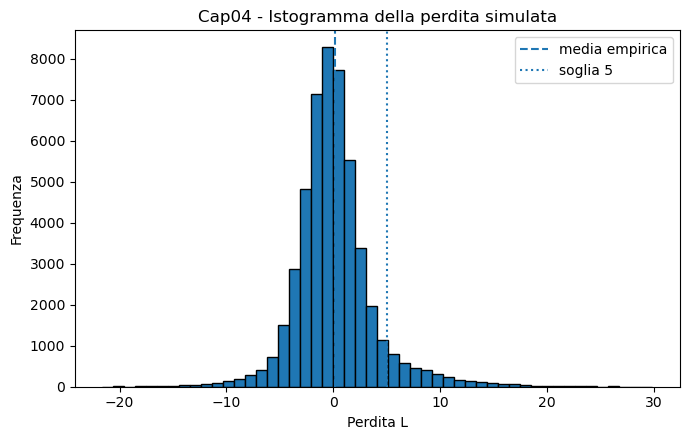

In [10]:
# ============================================================
# Blocco 5.3 - Istogramma della perdita
# ============================================================
# L'istogramma mostra la distribuzione empirica della variabile L.
# bins controlla il numero di intervalli; edgecolor rende visibili le barre.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["L"], bins=50, edgecolor="black")

# Aggiungiamo due riferimenti: la media empirica e la soglia di perdita ell_base.
ax.axvline(df["L"].mean(), linestyle="--", label="media empirica")
ax.axvline(ell_base, linestyle=":", label=f"soglia {ell_base:g}")

# Etichette e titolo rendono il grafico interpretabile anche fuori dal notebook.
ax.set_xlabel("Perdita L")
ax.set_ylabel("Frequenza")
ax.set_title("Cap04 - Istogramma della perdita simulata")
ax.legend()
fig.tight_layout()

# Salviamo il grafico nella cartella comune graphics/ per poterlo riusare
# nel manuale o nelle slides.
fig_path = GRAPHICS_DIR / "Cap04_istogramma_perdita.png"
fig.savefig(fig_path, dpi=200)

fig_path

WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_ecdf_perdita.png')

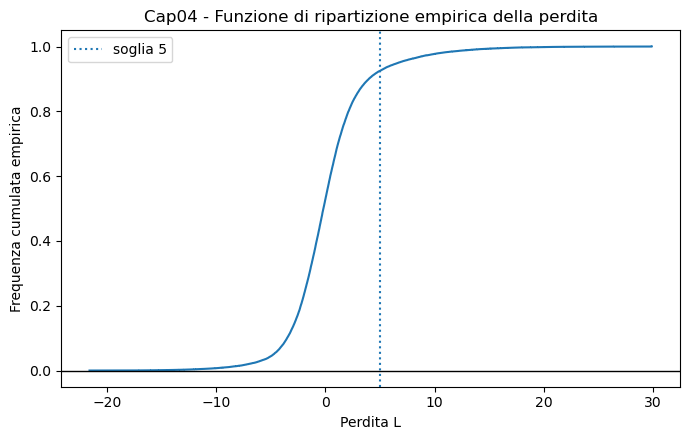

In [11]:
# ============================================================
# Blocco 5.4 - Funzione di ripartizione empirica
# ============================================================
# Per costruire la funzione di ripartizione empirica ordiniamo le perdite.
L_sorted = np.sort(df["L"].to_numpy())

# ecdf[k] rappresenta la frazione di osservazioni minori o uguali
# al k-esimo valore ordinato.
ecdf = np.arange(1, M + 1) / M

# Una funzione di ripartizione deve essere non decrescente.
assert np.all(np.diff(ecdf) >= 0), "La funzione di ripartizione empirica non è non decrescente."

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.step(L_sorted, ecdf, where="post")
ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(ell_base, linestyle=":", label=f"soglia {ell_base:g}")
ax.set_xlabel("Perdita L")
ax.set_ylabel("Frequenza cumulata empirica")
ax.set_title("Cap04 - Funzione di ripartizione empirica della perdita")
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_ecdf_perdita.png"
fig.savefig(fig_path, dpi=200)

fig_path

WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_quantili_perdita.png')

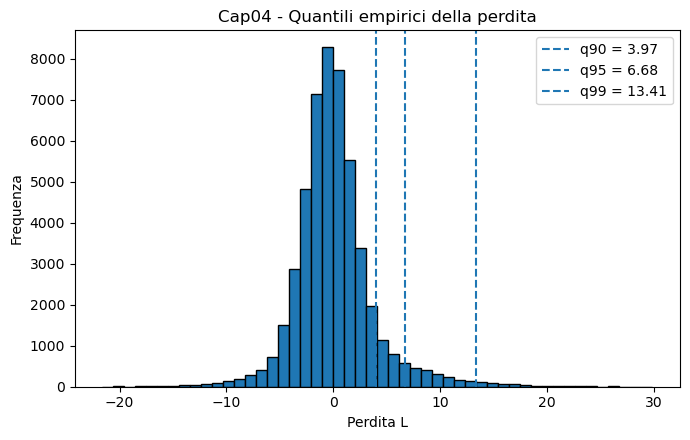

In [12]:
# ============================================================
# Blocco 5.5 - Istogramma con quantili di coda
# ============================================================
# Questo grafico riprende l'istogramma e mette in evidenza i quantili elevati,
# utili per ragionare sugli scenari di perdita piu' severi.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df["L"], bins=50, edgecolor="black")

# Il ciclo for evita di ripetere tre volte lo stesso blocco di codice.
for q in [0.90, 0.95, 0.99]:
    q_value = df["L"].quantile(q)
    ax.axvline(q_value, linestyle="--", label=f"q{int(q*100)} = {q_value:.2f}")

ax.set_xlabel("Perdita L")
ax.set_ylabel("Frequenza")
ax.set_title("Cap04 - Quantili empirici della perdita")
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_quantili_perdita.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 6 — Probabilità empirica di superamento soglia

Per una soglia $\ell$, l'evento di interesse è

$$A_\ell=\{L>\ell\}.$$
Lo stimatore Monte Carlo è 
$$\widehat{\mathbb{P}}(L>\ell)
=
\frac{1}{M}
\sum_{k=1}^{M}
\mathbf{1}_{\{L^{(k)}>\ell\}}.$$

**Controlli.**

- le probabilità devono essere comprese tra $0$ e $1$;
- la probabilità di superamento deve essere non crescente al crescere della soglia.

**Interpretazione.** La soglia definisce quale porzione della distribuzione viene considerata finanziariamente critica.

In [13]:
# ============================================================
# Blocco 6.1 - Probabilita' empiriche di superamento
# ============================================================
# Per ogni soglia ell stimiamo Prob(L > ell) come frequenza relativa degli scenari
# in cui la perdita simulata supera la soglia.
df_soglie = pd.DataFrame({
    "soglia_l": soglie_base,
    "prob_superamento_empirica": [(df["L"] > ell).mean() for ell in soglie_base],
    "numero_superamenti": [(df["L"] > ell).sum() for ell in soglie_base]
})

# ============================================================
# Blocco 6.2 - Controlli sulle probabilita'
# ============================================================
# Una probabilita' deve stare tra 0 e 1.
df_soglie["probabilita_valida"] = df_soglie["prob_superamento_empirica"].between(0, 1)

# Se la soglia aumenta, la probabilita' di superarla non puo' aumentare.
df_soglie["monotonia_non_crescente"] = (
    df_soglie["prob_superamento_empirica"].diff().fillna(0) <= 1e-12
)

assert df_soglie["probabilita_valida"].all(), "Una probabilità stimata non è valida."
assert df_soglie["monotonia_non_crescente"].all(), "La probabilità di superamento non è non crescente."

df_soglie

,soglia_l,prob_superamento_empirica,numero_superamenti,probabilita_valida,monotonia_non_crescente
0,2.0,0.20930,10465,True,True
1,5.0,0.07496,3748,True,True
2,8.0,0.03696,1848,True,True
3,10.0,0.02270,1135,True,True


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_prob_superamento_soglie.png')

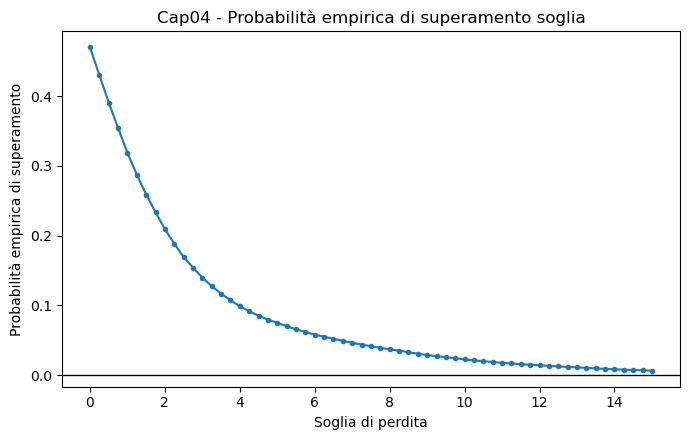

In [14]:
# ============================================================
# Blocco 6.3 - Curva di superamento per una griglia di soglie
# ============================================================
# linspace costruisce 61 soglie equidistanti tra 0 e 15.
soglia_grid = np.linspace(0, 15, 61)

# Ripetiamo la stima Prob(L > ell) su tutta la griglia di soglie.
df_soglie_grid = pd.DataFrame({
    "soglia_l": soglia_grid,
    "prob_superamento_empirica": [(df["L"] > ell).mean() for ell in soglia_grid]
})

# Controllo di monotonia della curva.
df_soglie_grid["monotonia_non_crescente"] = (
    df_soglie_grid["prob_superamento_empirica"].diff().fillna(0) <= 1e-12
)

assert df_soglie_grid["monotonia_non_crescente"].all(), "La curva di superamento soglia non è non crescente."

# Grafico della curva ell -> P(L > ell).
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_soglie_grid["soglia_l"], df_soglie_grid["prob_superamento_empirica"], marker="o", markersize=3)
ax.axhline(0, color="black", linewidth=1.0)
ax.set_xlabel("Soglia di perdita")
ax.set_ylabel("Probabilità empirica di superamento")
ax.set_title("Cap04 - Probabilità empirica di superamento soglia")
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_prob_superamento_soglie.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 7 — Valore atteso non condizionato della perdita

La stima Monte Carlo della perdita media non condizionata è

$$\widehat{\mathbb{E}}[L]
=
\frac{1}{M}\sum_{k=1}^{M}L^{(k)}.$$Nel modello parametrico scelto, la media teorica è$$\mathbb{E}[L]
=
-V_0\sum_g p_g\mu_g.$$

**Controllo.** La differenza tra media empirica e media teorica è errore Monte Carlo, non errore del modello.

**Interpretazione.** La media non condizionata aggrega tutti gli stati di mercato in un'unica previsione.

In [15]:
# ============================================================
# Blocco 7.1 - Media non condizionata della perdita
# ============================================================
# E_L_hat e' la stima Monte Carlo di E[L], ottenuta come media delle perdite.
E_L_hat = df["L"].mean()

# E_L_theory e' il valore teorico implicato dai parametri del modello:
# se L = -V0 * R, allora E[L] = -V0 * E[R].
E_L_theory = -V0 * np.sum(p * mu)

# La differenza Monte Carlo misura l'errore di simulazione.
diff_MC = E_L_hat - E_L_theory

df_media = pd.DataFrame({
    "quantita": ["E_hat[L]", "E_teorica[L]", "differenza_MC"],
    "valore": [E_L_hat, E_L_theory, diff_MC]
})

df_media

,quantita,valore
0,E_hat[L],0.130747
1,E_teorica[L],0.140000
2,differenza_MC,-0.009253


## Tappa 8 — Valori attesi condizionati rispetto agli stati

Per ogni stato informativo $g$, si stima

$$\mathbb{E}[L\mid Z=g].$$
Lo stimatore empirico è
$$\widehat{\mathbb{E}}[L\mid Z=g]
=
\frac{1}{M_g}
\sum_{k:Z^{(k)}=g}
L^{(k)},
\qquad
M_g=\#\{k:Z^{(k)}=g\}.$$

**Controllo.** Ogni classe deve avere numerosità positiva.

**Interpretazione.** Il valore atteso condizionato modifica la previsione quando lo stato è noto; non modifica le perdite simulate.

In [16]:
# ============================================================
# Blocco 8.1 - Statistiche condizionate per stato informativo
# ============================================================
# groupby("stato") crea un gruppo per ciascuna classe informativa.
# Per ogni stato stimiamo media, deviazione standard e alcuni quantili di L.
df_cond = (
    df.groupby("stato")
    .agg(
        M_g=("L", "size"),
        E_hat_L_cond=("L", "mean"),
        sd_L_cond=("L", "std"),
        q05_L_cond=("L", lambda x: x.quantile(0.05)),
        q50_L_cond=("L", lambda x: x.quantile(0.50)),
        q95_L_cond=("L", lambda x: x.quantile(0.95)),
    )
    .reindex(stati)
    .reset_index()
)

# Aggiungiamo la descrizione estesa dello stato.
df_cond["descrizione"] = df_cond["stato"].map(etichette)

# Riordiniamo le colonne in modo didattico: prima lo stato, poi numerosita'
# e statistiche condizionate.
df_cond = df_cond[
    ["stato", "descrizione", "M_g", "E_hat_L_cond", "sd_L_cond", "q05_L_cond", "q50_L_cond", "q95_L_cond"]
]

# Ogni media condizionata ha senso solo se la classe contiene almeno uno scenario.
df_cond["classe_non_vuota"] = df_cond["M_g"] > 0

assert df_cond["classe_non_vuota"].all(), "Almeno una classe informativa è vuota."

df_cond

,stato,descrizione,M_g,E_hat_L_cond,sd_L_cond,q05_L_cond,q50_L_cond,q95_L_cond,classe_non_vuota
0,N,mercato normale,34935,-0.403040,1.997022,-3.708424,-0.401453,2.887022,True
1,V,volatilità elevata,9995,0.554762,4.490516,-6.866056,0.573878,7.994352,True
2,S,stress,5070,2.972920,7.917922,-10.171320,3.037844,15.989130,True


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_medie_condizionate_stati.png')

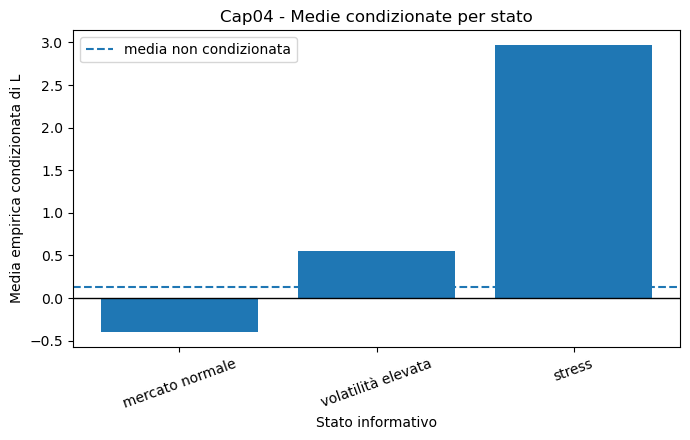

In [17]:
# ============================================================
# Blocco 8.2 - Grafico delle medie condizionate
# ============================================================
# Il grafico confronta E[L | stato] con la media non condizionata E[L].
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(df_cond["descrizione"], df_cond["E_hat_L_cond"])
ax.axhline(0, color="black", linewidth=1.0)
ax.axhline(df["L"].mean(), linestyle="--", label="media non condizionata")
ax.set_xlabel("Stato informativo")
ax.set_ylabel("Media empirica condizionata di L")
ax.set_title("Cap04 - Medie condizionate per stato")
ax.tick_params(axis="x", rotation=20)
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_medie_condizionate_stati.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 9 — Costruzione della variabile $\mathbb{E}[L\mid\mathcal{G}]$

La sigma-algebra informativa è generata dalla partizione degli stati:

$$\mathcal{G}=\sigma(A_N,A_V,A_S).$$
La variabile condizionata è
$$\mathbb{E}[L\mid\mathcal{G}]
=
\sum_g \mathbb{E}[L\mid Z=g]\mathbf{1}_{\{Z=g\}}.$$

**Controllo.** La variabile $\mathbb{E}[L\mid\mathcal{G}]$ deve essere costante all'interno di ciascuno stato.

**Interpretazione.** Questa previsione condizionata non è un numero: è una variabile casuale che assume valori diversi a seconda dello stato informativo.

In [18]:
# ============================================================
# Blocco 9.1 - Costruzione di E[L | G] come variabile casuale
# ============================================================
# cond_map associa a ogni stato la media condizionata stimata in df_cond.
cond_map = df_cond.set_index("stato")["E_hat_L_cond"]

# Per ogni scenario assegniamo il valore di E[L | G] corrispondente al suo stato.
# Il risultato e' una nuova colonna: e' costante dentro ogni classe informativa.
df["E_L_cond_G"] = df["stato"].map(cond_map)

# ============================================================
# Blocco 9.2 - Controllo: costanza dentro ciascuno stato
# ============================================================
# Se E[L | G] e' davvero condizionata alla partizione degli stati, deve assumere
# un solo valore per tutti gli scenari con lo stesso stato.
df_valori_cond = (
    df.groupby("stato")["E_L_cond_G"]
    .agg(
        numero_valori_distinti=lambda x: x.nunique(),
        valore="first"
    )
    .reindex(stati)
    .reset_index()
)

df_valori_cond["costante_nello_stato"] = (
    df_valori_cond["numero_valori_distinti"] == 1
)

assert df_valori_cond["costante_nello_stato"].all(), "E[L|G] non è costante in almeno uno stato."

df_valori_cond

,stato,numero_valori_distinti,valore,costante_nello_stato
0,N,1,-0.403040,True
1,V,1,0.554762,True
2,S,1,2.972920,True


## Tappa 10 — Controllo della proprietà a torre (Valore atteso condizionato iterato)

Si verifica numericamente la proprietà

$$\mathbb{E}\left[\mathbb{E}[L\mid\mathcal{G}]\right]
=
\mathbb{E}[L].$$

**Controllo.** La differenza tra le due medie empiriche deve essere nulla o trascurabile.

**Interpretazione.** Il condizionamento differenzia le previsioni tra stati, ma conserva la coerenza con la media aggregata.

In [19]:
# ============================================================
# Blocco 10.1 - Controllo della proprieta' a torre
# ============================================================
# La proprieta' a torre richiede E[E[L | G]] = E[L].
# Nel campione simulato confrontiamo le due medie empiriche.
E_E_L_cond_G_hat = df["E_L_cond_G"].mean()

df_torre = pd.DataFrame({
    "quantita": [
        "media_empirica_L",
        "media_empirica_E_L_cond_G",
        "differenza_assoluta"
    ],
    "valore": [
        E_L_hat,
        E_E_L_cond_G_hat,
        abs(E_L_hat - E_E_L_cond_G_hat)
    ]
})

# La differenza deve essere praticamente zero. La tolleranza 1e-10 serve
# solo per evitare problemi di arrotondamento numerico.
assert df_torre.loc[df_torre["quantita"] == "differenza_assoluta", "valore"].iloc[0] < 1e-10, (
    "Il controllo della proprietà della torre non è verificato."
)

df_torre

,quantita,valore
0,media_empirica_L,1.307472e-01
1,media_empirica_E_L_cond_G,1.307472e-01
2,differenza_assoluta,5.551115e-17


## Tappa 11 — Distribuzione non condizionata e distribuzioni condizionate

Si confronta la distribuzione complessiva della perdita con le distribuzioni condizionate agli stati.

**Controllo.** I quantili condizionati devono essere coerenti con la parametrizzazione: lo stato di stress dovrebbe presentare valori di coda più severi.

**Interpretazione.** La distribuzione non condizionata può nascondere eterogeneità rilevante tra stati informativi.

In [20]:
# ============================================================
# Blocco 11.1 - Quantili della perdita condizionati allo stato
# ============================================================
# Calcoliamo alcuni quantili di L separatamente per N, V e S.
# unstack trasforma i livelli di quantile in colonne della tabella.
df_quantili_stato = (
    df.groupby("stato")["L"]
    .quantile([0.05, 0.50, 0.95, 0.99])
    .unstack()
    .reindex(stati)
    .reset_index()
    .rename(columns={
        0.05: "q05",
        0.50: "q50",
        0.95: "q95",
        0.99: "q99"
    })
)

df_quantili_stato["descrizione"] = df_quantili_stato["stato"].map(etichette)
df_quantili_stato = df_quantili_stato[
    ["stato", "descrizione", "q05", "q50", "q95", "q99"]
]

df_quantili_stato

,stato,descrizione,q05,q50,q95,q99
0,N,mercato normale,-3.708424,-0.401453,2.887022,4.253819
1,V,volatilità elevata,-6.866056,0.573878,7.994352,11.048668
2,S,stress,-10.171320,3.037844,15.989130,21.434389


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_distribuzioni_condizionate.png')

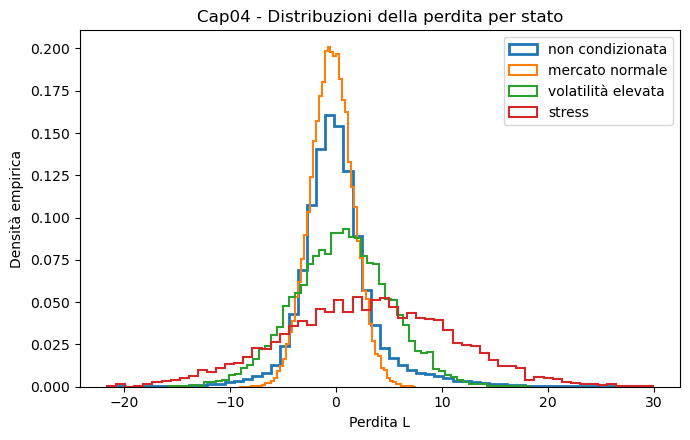

In [21]:
# ============================================================
# Blocco 11.2 - Confronto grafico tra distribuzione non condizionata
# e distribuzioni condizionate
# ============================================================
fig, ax = plt.subplots(figsize=(7, 4.5))

# Istogramma della perdita non condizionata: usa tutti gli scenari.
ax.hist(
    df["L"],
    bins=60,
    density=True,
    histtype="step",
    linewidth=2,
    label="non condizionata"
)

# Istogrammi condizionati: uno per ciascuno stato informativo.
for s in stati:
    ax.hist(
        df.loc[df["stato"] == s, "L"],
        bins=60,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=etichette[s]
    )

ax.set_xlabel("Perdita L")
ax.set_ylabel("Densità empirica")
ax.set_title("Cap04 - Distribuzioni della perdita per stato")
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_distribuzioni_condizionate.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 12 — Sensibilità al numero di simulazioni

Una stima Monte Carlo è una quantità casuale. Si ripete la stima per diversi valori di $M$.

**Controllo.** La variabilità delle stime tende a ridursi al crescere di $M$, senza richiedere monotonia perfetta.

**Interpretazione.** La numerosità degli scenari è parte della qualità computazionale del risultato.

In [22]:
# ============================================================
# Blocco 12.1 - Funzione per ripetere la simulazione con M diverso
# ============================================================
# Definiamo una funzione per evitare di copiare lo stesso codice molte volte.
# La funzione restituisce una piccola sintesi della simulazione.
def simula_sintesi(M_local: int, seed_local: int) -> dict:
    # Ogni simulazione usa un generatore locale, cosi' i confronti sono
    # riproducibili e non dipendono dall'ordine di esecuzione delle celle.
    local_rng = np.random.default_rng(seed_local)

    # 1. Simuliamo gli stati informativi.
    Z_local = local_rng.choice(stati, size=M_local, p=p)

    # 2. Recuperiamo mu e sigma coerenti con lo stato simulato.
    mu_local = pd.Series(Z_local).map(param_map["mu_rendimento"]).to_numpy()
    sigma_local = pd.Series(Z_local).map(param_map["sigma_rendimento"]).to_numpy()

    # 3. Simuliamo i rendimenti e trasformiamoli in perdite.
    R_local = local_rng.normal(mu_local, sigma_local)
    L_local = -V0 * R_local

    # 4. Restituiamo solo le grandezze necessarie per il confronto.
    return {
        "M": M_local,
        "E_hat_L": L_local.mean(),
        "P_hat_L_gt_5": (L_local > 5.0).mean(),
        "sd_L": L_local.std(ddof=1)
    }

# ============================================================
# Blocco 12.2 - Confronto tra diverse numerosita' Monte Carlo
# ============================================================
# Al crescere di M, le stime Monte Carlo dovrebbero diventare piu' stabili.
valori_M = [50, 100, 500, 1_000, 5_000, 10_000, 50_000]

df_sens_M = pd.DataFrame([
    simula_sintesi(m, seed + m) for m in valori_M
])

df_sens_M

,M,E_hat_L,P_hat_L_gt_5,sd_L
0,50,1.512085,0.16000,5.099545
1,100,-0.170679,0.06000,3.098634
2,500,0.212006,0.09000,3.799949
3,1000,0.114513,0.07500,3.651989
4,5000,0.255522,0.08120,3.814100
5,10000,0.156819,0.07640,3.927263
6,50000,0.132701,0.07534,3.801480


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_sensibilita_M.png')

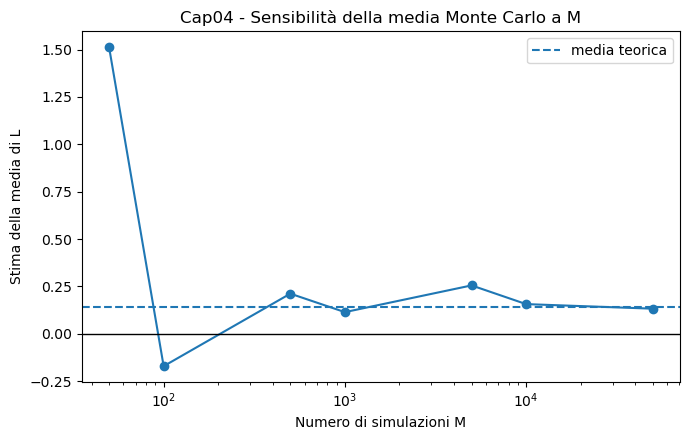

In [23]:
# ============================================================
# Blocco 12.3 - Grafico della sensibilita' a M
# ============================================================
# Rappresentiamo la stima della media al variare del numero di simulazioni.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_sens_M["M"], df_sens_M["E_hat_L"], marker="o")
ax.axhline(0, color="black", linewidth=1.0)
ax.axhline(E_L_theory, linestyle="--", label="media teorica")
ax.set_xlabel("Numero di simulazioni M")
ax.set_ylabel("Stima della media di L")
ax.set_title("Cap04 - Sensibilità della media Monte Carlo a M")

# La scala logaritmica rende leggibili valori di M molto diversi tra loro.
ax.set_xscale("log")
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_sensibilita_M.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 13 — Sensibilità alla soglia di perdita

Si analizza la funzione empirica

$$\ell \mapsto \widehat{\mathbb{P}}(L>\ell).$$

**Controllo.** La funzione deve essere non crescente.

**Interpretazione.** La soglia determina quale area della distribuzione viene letta come evento di rischio.

In [24]:
# ============================================================
# Blocco 13.1 - Richiamo della tabella gia' costruita
# ============================================================
# La tabella df_soglie_grid e la figura Cap04_prob_superamento_soglie.png
# sono state gia' costruite nella Tappa 6.
# head(10) mostra solo le prime dieci righe, utile per controllare rapidamente
# la struttura della tabella senza stamparla tutta.
df_soglie_grid.head(10)

,soglia_l,prob_superamento_empirica,monotonia_non_crescente
0,0.00,0.46974,True
1,0.25,0.43028,True
2,0.50,0.39080,True
3,0.75,0.35430,True
4,1.00,0.31886,True
5,1.25,0.28730,True
6,1.50,0.25890,True
7,1.75,0.23348,True
8,2.00,0.20930,True
9,2.25,0.18846,True


## Tappa 14 — Partizione informativa grossolana e partizione informativa fine

Si confrontano due livelli informativi:

$$\mathcal{G}_1=\sigma(\text{normale},\text{non normale})$$e$$\mathcal{G}_2=\sigma(\text{normale},\text{volatilità elevata},\text{stress}).$$

**Controllo.** Entrambe le previsioni condizionate devono rispettare la coerenza aggregata.

**Interpretazione.** Una partizione più fine produce previsioni più differenziate, ma non altera la media non condizionata.

In [25]:
# ============================================================
# Blocco 14.1 - Costruzione di una partizione informativa grossolana
# ============================================================
# La partizione fine distingue N, V e S. La partizione grossolana distingue
# solo mercato normale e mercato non normale.
df["stato_grossolano"] = np.where(
    df["stato"] == "N",
    "normale",
    "non normale"
)

# Media condizionata rispetto alla partizione grossolana G1.
cond_gross = df.groupby("stato_grossolano")["L"].mean()

# E[L | G1] usa due classi; E[L | G2] usa le tre classi N, V, S.
df["E_L_cond_G1"] = df["stato_grossolano"].map(cond_gross)
df["E_L_cond_G2"] = df["E_L_cond_G"]

# ============================================================
# Blocco 14.2 - Tabelle di confronto tra partizioni
# ============================================================
# concat unisce due tabelle: una per G1 e una per G2.
df_partizioni = pd.concat([
    (
        df.groupby("stato_grossolano")
        .agg(M_g=("L", "size"), E_hat_L_cond=("L", "mean"))
        .reset_index()
        .rename(columns={"stato_grossolano": "classe"})
        .assign(partizione="G1: normale / non normale")
    ),
    (
        df.groupby("stato")
        .agg(M_g=("L", "size"), E_hat_L_cond=("L", "mean"))
        .reset_index()
        .rename(columns={"stato": "classe"})
        .assign(partizione="G2: N / V / S")
    )
], ignore_index=True)

df_partizioni = df_partizioni[
    ["partizione", "classe", "M_g", "E_hat_L_cond"]
]

# ============================================================
# Blocco 14.3 - Coerenza delle medie condizionate
# ============================================================
# Anche usando partizioni diverse, la media della variabile condizionata
# deve restituire la media non condizionata.
df_coerenza_partizioni = pd.DataFrame({
    "quantita": [
        "E_hat[L]",
        "E_hat[E[L|G1]]",
        "E_hat[E[L|G2]]"
    ],
    "valore": [
        df["L"].mean(),
        df["E_L_cond_G1"].mean(),
        df["E_L_cond_G2"].mean()
    ]
})

df_coerenza_partizioni["differenza_da_E_hat_L"] = (
    df_coerenza_partizioni["valore"]
    - df["L"].mean()
)

assert np.allclose(
    df_coerenza_partizioni["differenza_da_E_hat_L"].to_numpy(),
    0.0
), "La coerenza delle partizioni non è verificata."

df_partizioni

,partizione,classe,M_g,E_hat_L_cond
0,G1: normale / non normale,non normale,15065,1.368573
1,G1: normale / non normale,normale,34935,-0.403040
2,G2: N / V / S,N,34935,-0.403040
3,G2: N / V / S,S,5070,2.972920
4,G2: N / V / S,V,9995,0.554762


In [26]:
# Mostriamo il controllo numerico della proprieta' a torre per entrambe
# le partizioni informative.
df_coerenza_partizioni

,quantita,valore,differenza_da_E_hat_L
0,E_hat[L],0.130747,0.000000e+00
1,E_hat[E[L|G1]],0.130747,8.326673e-17
2,E_hat[E[L|G2]],0.130747,5.551115e-17


WindowsPath('e:/Didattica/MQF/Github/CORSO-MQF/graphics/Cap04_partizioni_informative.png')

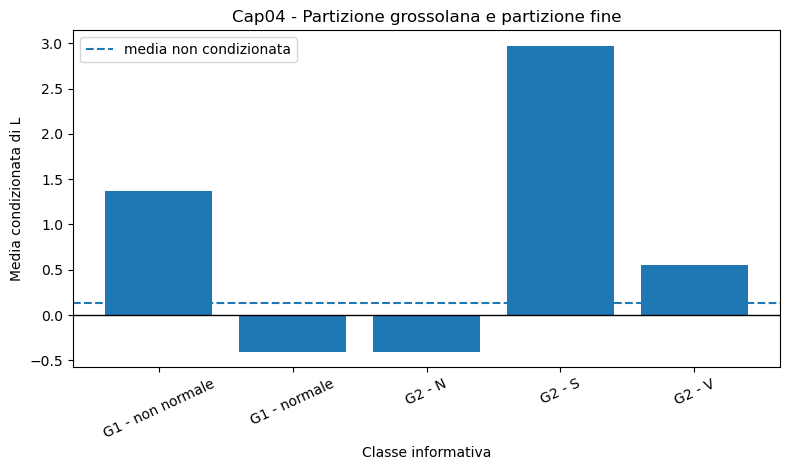

In [27]:
# ============================================================
# Blocco 14.4 - Grafico del confronto tra partizioni
# ============================================================
# copy evita di modificare accidentalmente df_partizioni mentre prepariamo
# etichette piu' adatte al grafico.
plot_part = df_partizioni.copy()

# Estraiamo G1 o G2 dal nome della partizione per costruire etichette compatte.
prefisso = plot_part["partizione"].str.extract(r"(G\d)", expand=False).fillna("")
plot_part["etichetta"] = prefisso + " - " + plot_part["classe"].astype(str)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.bar(plot_part["etichetta"], plot_part["E_hat_L_cond"])
ax.axhline(0, color="black", linewidth=1.0)
ax.axhline(df["L"].mean(), linestyle="--", label="media non condizionata")
ax.set_xlabel("Classe informativa")
ax.set_ylabel("Media condizionata di L")
ax.set_title("Cap04 - Partizione grossolana e partizione fine")
ax.tick_params(axis="x", rotation=25)
ax.legend()
fig.tight_layout()

fig_path = GRAPHICS_DIR / "Cap04_partizioni_informative.png"
fig.savefig(fig_path, dpi=200)

fig_path

## Tappa 15 — Esportazione ordinata di dati, tabelle e figure

**Obiettivo.** Rendere il prodotto computazionale riproducibile.

**Controllo.** I file devono essere creati e non devono essere vuoti.

**Interpretazione.** Il notebook produce oggetti riutilizzabili per manuale e slides: dati simulati, tabelle e figure.

In [28]:
# ============================================================
# Blocco 15.1 - Elenco delle tabelle da esportare
# ============================================================
# Il dizionario associa a ogni nome di file la tabella pandas da salvare.
# Questa scelta rende l'esportazione ordinata e facilmente controllabile.
tabelle = {
    "Lez04_parametri_generali.csv": tabella_generale,
    "Lez04_tabella_parametri.csv": df_parametri,
    "Lez04_frequenze_stati.csv": df_frequenze,
    "Lez04_statistiche_rendimenti_per_stato.csv": df_stat_R_stato,
    "Lez04_scenari_perdita.csv": df,
    "Lez04_controllo_segno.csv": controllo_segno,
    "Lez04_statistiche_perdita.csv": statistiche_L,
    "Lez04_quantili_perdita.csv": df_quantili,
    "Lez04_prob_superamento_soglie_base.csv": df_soglie,
    "Lez04_media_non_condizionata.csv": df_media,
    "Lez04_statistiche_condizionate.csv": df_cond,
    "Lez04_valori_E_L_cond_G.csv": df_valori_cond,
    "Lez04_controllo_torre.csv": df_torre,
    "Lez04_quantili_per_stato.csv": df_quantili_stato,
    "Lez04_sensibilita_M.csv": df_sens_M,
    "Lez04_prob_superamento_griglia_soglie.csv": df_soglie_grid,
    "Lez04_confronto_partizioni.csv": df_partizioni,
    "Lez04_coerenza_partizioni.csv": df_coerenza_partizioni,
}

# ============================================================
# Blocco 15.2 - Scrittura delle tabelle CSV
# ============================================================
# Il ciclo salva ogni tabella nella cartella output_Lez04.
# index=False evita di aggiungere una colonna artificiale con l'indice pandas.
for nome_file, tabella in tabelle.items():
    tabella.to_csv(OUTPUT_DIR / nome_file, index=False)

# ============================================================
# Blocco 15.3 - Elenco delle figure attese
# ============================================================
# Usiamo questa lista per controllare che tutti i grafici siano stati creati.
figure_attese = [
    "Cap04_istogramma_perdita.png",
    "Cap04_ecdf_perdita.png",
    "Cap04_quantili_perdita.png",
    "Cap04_medie_condizionate_stati.png",
    "Cap04_prob_superamento_soglie.png",
    "Cap04_distribuzioni_condizionate.png",
    "Cap04_sensibilita_M.png",
    "Cap04_partizioni_informative.png",
]

# ============================================================
# Blocco 15.4 - Controllo finale dei file prodotti
# ============================================================
# controllo_file sara' una lista di righe, poi convertita in DataFrame.
controllo_file = []

# Controllo delle tabelle CSV.
for nome_file in tabelle:
    path = OUTPUT_DIR / nome_file
    controllo_file.append({
        "tipo": "tabella",
        "file": str(path),
        "esiste": path.exists(),
        "dimensione_byte": path.stat().st_size if path.exists() else 0
    })

# Controllo delle figure PNG.
for nome_file in figure_attese:
    path = GRAPHICS_DIR / nome_file
    controllo_file.append({
        "tipo": "figura",
        "file": str(path),
        "esiste": path.exists(),
        "dimensione_byte": path.stat().st_size if path.exists() else 0
    })

df_controllo_file = pd.DataFrame(controllo_file)
df_controllo_file["non_vuoto"] = df_controllo_file["dimensione_byte"] > 0

# Se manca un file oppure un file e' vuoto, il notebook segnala subito
# che l'esportazione non e' completa.
assert df_controllo_file["esiste"].all(), "Almeno un file atteso non è stato creato."
assert df_controllo_file["non_vuoto"].all(), "Almeno un file atteso è vuoto."

df_controllo_file

,tipo,file,esiste,dimensione_byte,non_vuoto
0,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,71,True
1,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,169,True
2,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,255,True
3,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,308,True
4,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,6723487,True
5,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,75,True
6,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,179,True
7,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,242,True
8,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,210,True
9,tabella,e:\Didattica\MQF\Github\CORSO-MQF\04_Codice\ou...,True,102,True


## Sintesi interpretativa per il docente

Il notebook realizza il seguente percorso:

$$\text{stato informativo}
\longrightarrow
\text{rendimento}
\longrightarrow
\text{perdita}
\longrightarrow
\text{distribuzione empirica}
\longrightarrow
\text{evento}
\longrightarrow
\text{previsione condizionata}.$$Il punto concettuale da enfatizzare in aula è che il valore atteso condizionato rispetto a $\mathcal{G}$ non è un singolo numero, ma una variabile casuale costante sugli elementi della partizione informativa.

La proprietà 
$$\mathbb{E}\left[\mathbb{E}[L\mid\mathcal{G}]\right]
=
\mathbb{E}[L]$$

è verificata numericamente dalla costruzione stessa della colonna `E_L_cond_G`.